## Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from IPython.display import display
import  warnings
warnings.filterwarnings("ignore")
%matplotlib inline

## Load Datasets

In [2]:
train_df = pd.read_csv("/Users/joyngugi/PycharmProjects/cGAN_LSTM_Clustering_FLFramework/data/rossmann-store-sales/train.csv", parse_dates=['Date'])
test_df = pd.read_csv("/Users/joyngugi/PycharmProjects/cGAN_LSTM_Clustering_FLFramework/data/rossmann-store-sales/test.csv", parse_dates=['Date'])
store_df = pd.read_csv("/Users/joyngugi/PycharmProjects/cGAN_LSTM_Clustering_FLFramework/data/rossmann-store-sales/store.csv")

In [3]:
print("Train DataFrame Shape:", train_df.shape)
print("Test DataFrame Shape:", test_df.shape)
print("Store DataFrame Shape:", store_df.shape)


Train DataFrame Shape: (1017209, 9)
Test DataFrame Shape: (41088, 8)
Store DataFrame Shape: (1115, 10)


In [4]:
train_df.head(50)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
5,6,5,2015-07-31,5651,589,1,1,0,1
6,7,5,2015-07-31,15344,1414,1,1,0,1
7,8,5,2015-07-31,8492,833,1,1,0,1
8,9,5,2015-07-31,8565,687,1,1,0,1
9,10,5,2015-07-31,7185,681,1,1,0,1


In [5]:
test_df.head(50)

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
5,6,10,4,2015-09-17,1.0,1,0,0
6,7,11,4,2015-09-17,1.0,1,0,0
7,8,12,4,2015-09-17,1.0,1,0,0
8,9,13,4,2015-09-17,1.0,1,0,0
9,10,14,4,2015-09-17,1.0,1,0,0


In [6]:
store_df.head(50)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
7,8,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
8,9,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
9,10,a,a,3160.0,9.0,2009.0,0,NaN,NaN,NaN


## Merge Datasets

In [7]:
train_merged_df = train_df.merge(store_df, on='Store', how='left')
test_merged_df = test_df.merge(store_df, on='Store', how='left')

In [8]:
train_merged_df.shape

(1017209, 18)

In [9]:
train_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

Dataset Description:
- Id - Unique identifier for the row within the test set.
- Store - Unique ID for each store
- DayOfWeek - Day of the week (1 = Monday to 7 = Sunday).
- Date - The specific date of the record.
- Sales - Total sales for that store on the given date.
- Customers - Number of customers on a given day.
- Open - Whether the store was open (1 = Open, 0 = Closed).
- StateHoliday - Indicates a state holiday: '0' = No holiday, 'a' = Public holiday, 'b' = Easter holiday, 'c' = Christmas.
- SchoolHoliday - 	Whether there was a school holiday (1 = Yes, 0 = No).
- StoreType - The type of store (a, b, c, or d).
- Assortment - Assortment level: 'a' = basic, 'b' = extra, 'c' = extended.
- CompetitionDistance - Distance to the nearest competitor store (meters).
- CompetitionOpenSince[Month/Year] - Month/Year the nearest competitor opened.
- Promo - Whether a store is running a promo on that day (1 = Yes, 0 = No).
- Promo2 - Whether the store is participating in the continuing promotion (1 = Yes, 0 = No).
- Promo2Since[Year/Week] - The year/calendar week number when Promo2 started.
- PromoInterval - Describes the consecutive intervals Promo2 is started, naming the months the promotion is started anew. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that store


In [10]:
train_merged_df.head(50)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,5,2015-07-31,5651,589,1,1,0,1,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,5,2015-07-31,15344,1414,1,1,0,1,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
7,8,5,2015-07-31,8492,833,1,1,0,1,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
8,9,5,2015-07-31,8565,687,1,1,0,1,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
9,10,5,2015-07-31,7185,681,1,1,0,1,a,a,3160.0,9.0,2009.0,0,NaN,NaN,NaN


## Data Cleaning

### Missing Data

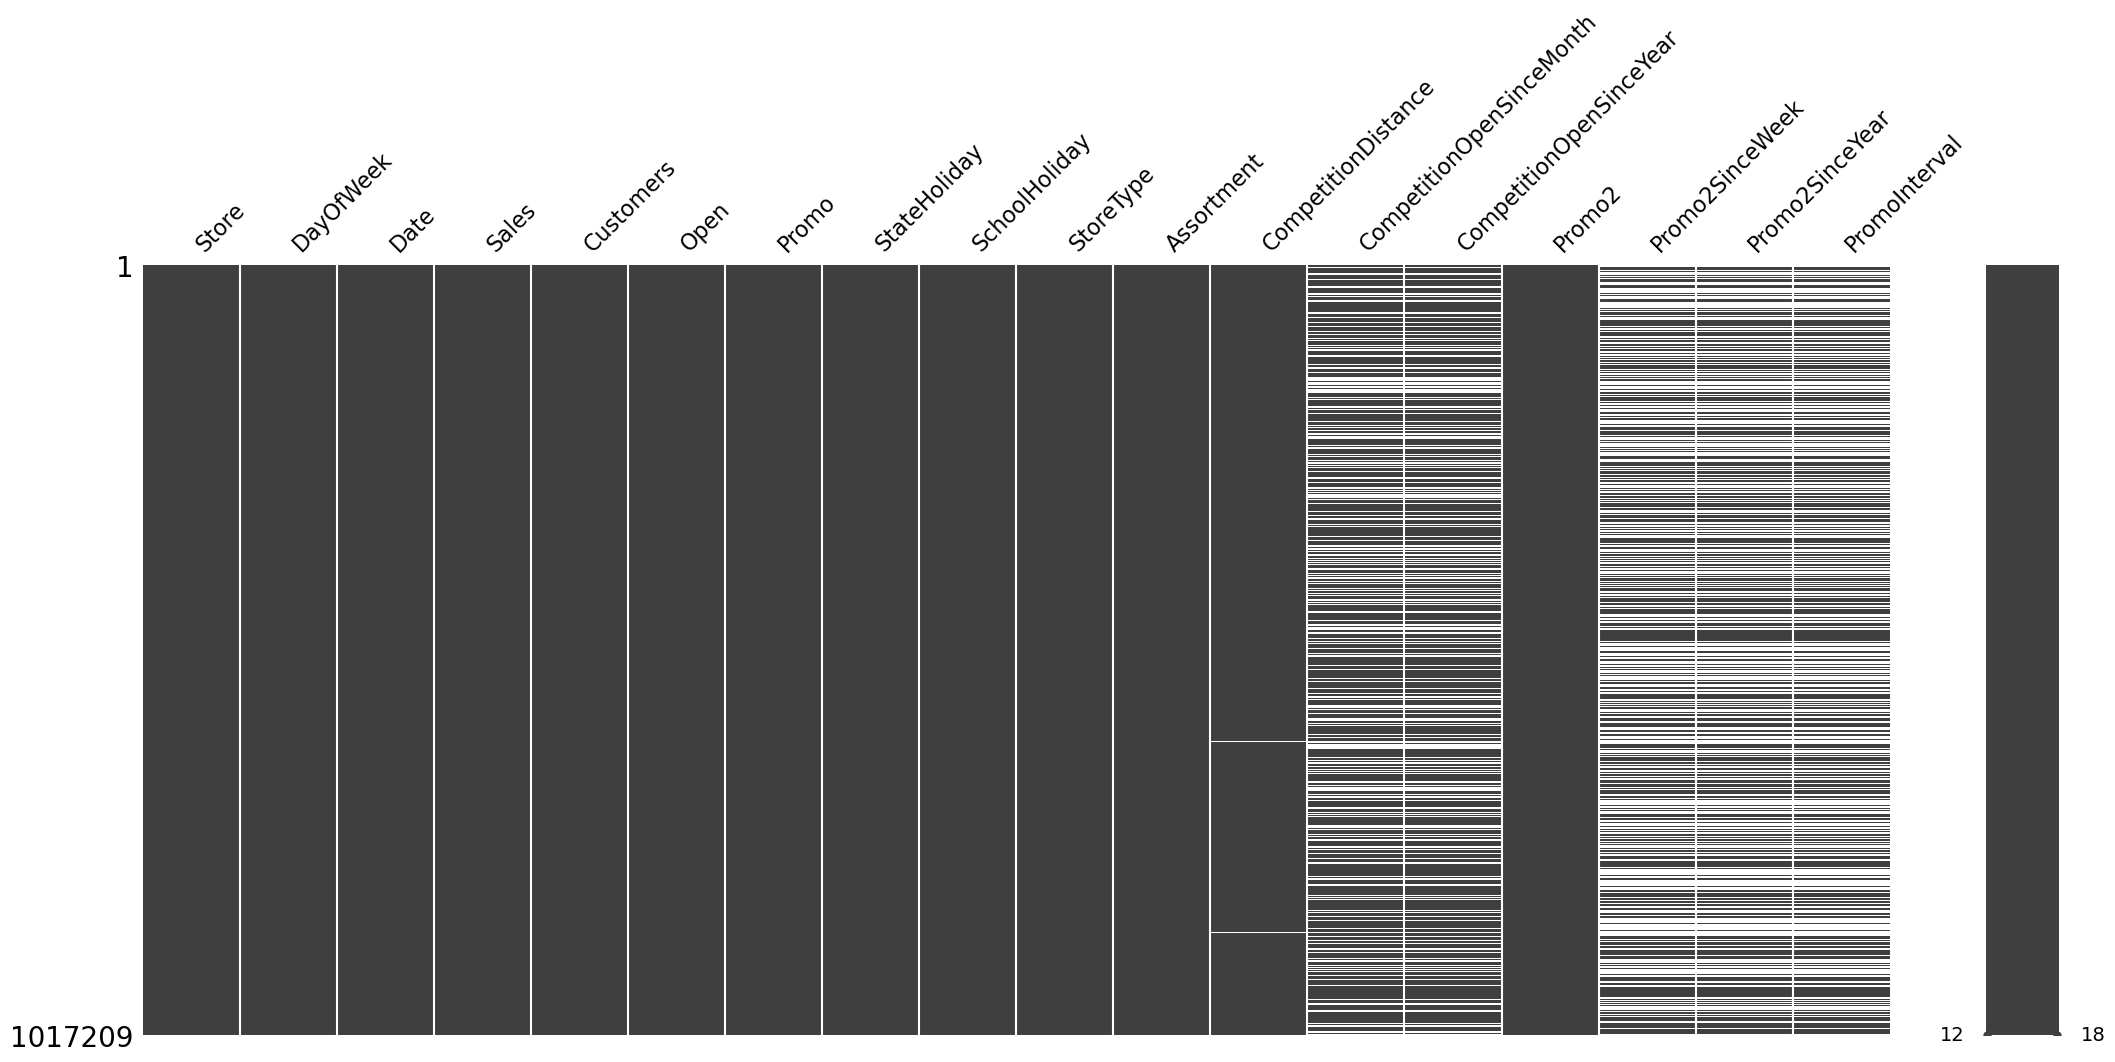

In [11]:
#Checking for missing values
msno.matrix(train_merged_df)
plt.show()

>> The competition and Promotion columns are the ones with the missing values, lets explore this further to understand how to handle them

In [12]:
# Quantifying the missingness per column
missing_numbers = train_merged_df.isnull().sum()
missing_percentages = train_merged_df.isnull().mean()
print(f"Number of missing values for each column:\n {missing_numbers}")
print(f"Percentage of missing values for each column:\n {missing_percentages}")

Number of missing values for each column:
 Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64
Percentage of missing values for each column:
 Store                        0.000000
DayOfWeek                    0.000000
Date                         0.000000
Sales                        0.000000
Customers                    0.000000
Open                         0.000000
Promo                

>> - CompetitionOpenSinceMonth and CompetitionOpenSinceMonth **(323348)** have the same number of missing values as well as Promo2SinceWeek,Promo2SinceYear and PromoInterval **(508031)** , CompetitionDistance is **(2642)**.
>> - Could there be a Correlation between the missing values of Promo2SinceWeek,Promo2SinceYear and PromoInterval and when there was no Promotion i.e. Promo2 = 0? Lets check

#### Promotion Missing Data 

In [13]:
# Create a copy of the dataframe to aid in investigation
train_merged_df_missing = train_merged_df.copy()

In [14]:
train_merged_df_missing.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

Correlation Matrix:


,Promo2SinceWeek_missing,Promo2SinceYear_missing,PromoInterval_missing,Promo2
Promo2SinceWeek_missing,1.0,1.0,1.0,-1.0
Promo2SinceYear_missing,1.0,1.0,1.0,-1.0
PromoInterval_missing,1.0,1.0,1.0,-1.0
Promo2,-1.0,-1.0,-1.0,1.0


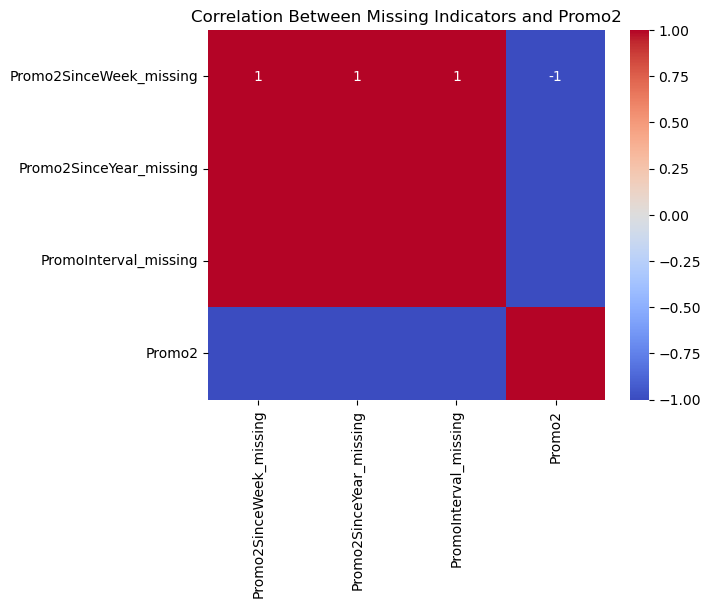


Missing Value Rates by Promo2:


,Promo2SinceWeek_missing,Promo2SinceYear_missing,PromoInterval_missing
Promo2,,,
0,1.0,1.0,1.0
1,0.0,0.0,0.0


In [15]:
# Step 1: Create binary missing indicator columns.
train_merged_df_missing['Promo2SinceWeek_missing'] = train_merged_df_missing['Promo2SinceWeek'].isnull().astype(int)
train_merged_df_missing['Promo2SinceYear_missing'] = train_merged_df_missing['Promo2SinceYear'].isnull().astype(int)
train_merged_df_missing['PromoInterval_missing'] = train_merged_df_missing['PromoInterval'].isnull().astype(int)

# Step 2: Compute correlation matrix with the Promo2 column.
corr_matrix = train_merged_df_missing[['Promo2SinceWeek_missing', 
                        'Promo2SinceYear_missing', 
                        'PromoInterval_missing', 
                        'Promo2']].corr()
print("Correlation Matrix:")
display(corr_matrix)

# Visualize the correlation matrix.
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Between Missing Indicators and Promo2')
plt.show()

# Step 3: Compare missing rates for each Promo2 group.
missing_rates = train_merged_df_missing.groupby('Promo2')[['Promo2SinceWeek_missing', 
                                              'Promo2SinceYear_missing', 
                                              'PromoInterval_missing']].mean()
print("\nMissing Value Rates by Promo2:")
display(missing_rates)


>> From the above correlation report, the following assumptions can be made:
- The same rows missing for Promo2SinceWeek are the same for Promo2SinceYear as well as PromoInterval.
- The missing values are not missing at Random, there is a perfect alignment of missigness with when there is no promotion, therefore we will no leave them as missing for now and decide how to represent there missingness with either ) for Promo2SinceWeek and Promo2SinceYear or “No continuing promotion” for PromoInterval

In [16]:
# Impute in the main dataframe
train_merged_df['Promo2SinceWeek'] = train_merged_df['Promo2SinceWeek'].fillna(0)
train_merged_df['Promo2SinceYear'] = train_merged_df['Promo2SinceYear'].fillna(0)
train_merged_df['PromoInterval']   = train_merged_df['PromoInterval'].fillna("No continuing promotion")


In [17]:
train_merged_df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek                   0
Promo2SinceYear                   0
PromoInterval                     0
dtype: int64

#### Competition Missing Data

In [18]:
# checking for Patterns 
# Maybe store-specific?
missing_summary = (
    train_merged_df
    .groupby('Store')[['CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']]
    .apply(lambda x: x.isnull().sum())
)


stores_with_missing = missing_summary[
    (missing_summary['CompetitionDistance'] > 0) |
    (missing_summary['CompetitionOpenSinceMonth'] > 0) |
    (missing_summary['CompetitionOpenSinceYear'] > 0)
]

pd.set_option('display.max_rows', None)
display(stores_with_missing)



,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear
Store,,,
12,0,942,942
13,0,758,758
16,0,942,942
19,0,942,942
22,0,758,758
26,0,942,942
29,0,942,942
32,0,758,758
40,0,942,942


In [19]:
print(store_df[['CompetitionDistance',
                'CompetitionOpenSinceMonth',
                'CompetitionOpenSinceYear']].isnull().sum())


CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
dtype: int64


>> From the above the following assumptions can be made:
- assumption1 -> The number of stores with missing data for CompetitionDistance is 3 and, CompetitionOpenSinceMonth and CompetitionOpenSinceYear is 354.
- assumption2 -> The three for CompetitionDistance (291,622,879) also has the same missing values for CompetitionOpenSinceMonth and CompetitionOpenSinceYear **942, 942, and 758** consecutively. What we dont know is if these missing values are on the same records, likely, but we need to confirm.
- assumption -> Both the columns CompetitionOpenSinceMonth and CompetitionOpenSinceYear have the same missing values in all stores, Could they also have the same records with missing values, lets confirm.

> Testing assumption2

In [20]:
# Define the stores you want to check
stores_to_check = [291, 622, 879]

# Filter the DataFrame to only include these stores
subset_1 = train_merged_df[train_merged_df['Store'].isin(stores_to_check)]

# Create missing masks for each column in the subset
mask_distance = subset_1['CompetitionDistance'].isnull()
mask_month = subset_1['CompetitionOpenSinceMonth'].isnull()
mask_year = subset_1['CompetitionOpenSinceYear'].isnull()

# Check if the masks are identical:
aligned = mask_distance.equals(mask_month) and mask_distance.equals(mask_year)
print("Are missing values aligned across all three columns?", aligned)


Are missing values aligned across all three columns? True


>> From the above we can confirm:
- Stores 291,622,879 have mising values for the same records

> Testing assumption3

In [21]:
# Filter the dataframe for rows where missingness doesn't match
mismatch_rows = train_merged_df.loc[
    train_merged_df['CompetitionOpenSinceMonth'].isnull() !=
    train_merged_df['CompetitionOpenSinceYear'].isnull()
]

print("Number of mismatched rows:", len(mismatch_rows))
mismatch_rows.head()


Number of mismatched rows: 0


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval


>> From the above we can confirm:
- All the records with mising values for CompetitionOpenSinceMonth and CompetitionOpenSinceYear are the same across the two columns.


>> From the observations:

1. Stores 291, 622, 879 (Group A):

- Missing values across all three competition columns (CompetitionDistance, CompetitionOpenSinceMonth, CompetitionOpenSinceYear) for every row.
- That implies there is zero competition info for these stores.
2. For the remaining 351 stores in the missing set (Group B):

- They have CompetitionDistance available, but are missing CompetitionOpenSinceMonth and CompetitionOpenSinceYear.
- So we have a partial picture: we know the distance to a competitor but not the date when that competitor opened.

>> Dealing with the competition missing values

In [22]:
# For the Group A stores (291, 622, 879):
groupA_stores = [291, 622, 879]
mask_groupA = train_merged_df['Store'].isin(groupA_stores)


# You may keep the missing flags as well:
train_merged_df['HasNoCompetitionData'] = 0
train_merged_df.loc[mask_groupA, 'HasNoCompetitionData'] = 1


In [23]:
train_merged_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'HasNoCompetitionData'],
      dtype='object')

In [28]:
train_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 19 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

In [29]:
train_merged_df['CompetitionDistance'] = train_merged_df['CompetitionDistance'].fillna(0)
train_merged_df['CompetitionOpenSinceMonth'] = train_merged_df['CompetitionOpenSinceMonth'].fillna(0)
train_merged_df['CompetitionOpenSinceYear']   = train_merged_df['CompetitionOpenSinceYear'].fillna(0)

In [30]:
train_merged_df.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
HasNoCompetitionData         0
dtype: int64

>> For the "Group A" stores that have no competition information recorded, we create a new indicator column "HasNoCompetitionData" and set it to 1. 
We then impute all missing competition-related columns (e.g., CompetitionDistance, CompetitionOpenSinceMonth/Year) with 0 for these stores, ensuring the model can distinguish between genuinely missing data and valid zero values.


### Check for Duplicates Records

In [31]:
train_merged_df.duplicated(subset=['Store','Date']).sum()

0

>> No duplicates for Store–Date combination, the reason this was checked is to make sure there is no sales data for one date recorded more than once for each individual store, as the assumption is that the records are an aggregation of the sales made for different stores for each specific date, so therefore having a store-date combination appering more than could lead to a suspicion of erroneous data entry.

### Data Type Corrections

In [33]:
train_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 19 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1017209 no

>> Already Parsed date to the correct data type.

### Check for Contradictory Sales

In [39]:
contradictory = train_merged_df[(train_merged_df['Open'] == 0) & (train_merged_df['Sales'] > 0)]
print("Contradictory records (closed but sales > 0):", len(contradictory))

Contradictory records (closed but sales > 0): 0


In [41]:
negative_sales = train_merged_df[(train_merged_df['Open'] == 1) & (train_merged_df['Sales'] < 0)]
print("Number of records with negative sales:", len(negative_sales))


Number of records with negative sales: 0


>> No Contradictory Sales